# Foliage Analysis - ASC Final Project

__HILARIOUS ATTEMPT TO MAKE THIS A GIANT PROGRAM__

* Author....Ryan Poulsen
* Created...11/04/2025
* Updated...12/10/2025

Made with <3, fueled by mint tea and chocolate chips.

___RQ) How is the timing of fall foliage changing in Shenandoah National Park as a result of climate change?___

Using imagery from Moderate Resolution Imaging Spectroradiometer (MODIS), I aim to determine how the timing of peak fall foliage in Shenandoah National Park is affected by climate change. I am focused on a 25-year window from 2000 to 2025, since MODIS started collecting data in 2000. To determine peak fall foliage date, I must calculate the Normalized Brownness Index (NBI) with the data.

The code in this project used IDL code from many a year ago from Dr. Spera as a jumping off point, I also frequently referred to Zhang et al. 2011's methods section for more in-depth methodology and theoretical descriptions.

See [Zhang et al., 2011](https://www.sciencedirect.com/science/article/pii/S0034425710002828) and [Spera et al., 2023](https://link.springer.com/article/10.1007/s10980-023-01703-0) for more information on methodology.

### Imports

In [2]:
# data
import pandas as pd
import numpy as np

# raster
import xarray as xr
import rioxarray as rxr

# file management
import os
import glob

# scipy
from scipy import interpolate, optimize, signal

# visualization
import matplotlib.pyplot as plt

### Raster Functions

In [3]:
def temporal_stack(data_src: str) -> xr.DataArray:
    """
    Reads in MODIS data from a directory, then creates a new `DataArray` on the dimension *doy*.
    ### Parameters
    * **data_src**: `str`
        * Path to the directory with the data.
    ### Returns
    * `DataArray`
        * The new `DataArray` stacked by *doy*.
    """
    rasters = sorted(glob.glob(os.path.expanduser(data_src))) # Get all paths to files in data_src
    crs_src = rxr.open_rasterio(rasters[0], masked=True).squeeze("band", drop=True).rio.crs # Get the crs of the first raster in the directory to use as template for the others to ensure all rasters match.

    rsts, doys = [], []
    year = 0
    for r in rasters:
        rio_r = rxr.open_rasterio(r, masked=True).squeeze("band", drop=True)
        year, doy = get_date(r)
        rio_r.rio.reproject(crs_src) # Might not be necessary, but is probably good practice to ensure that all rasters are in the same crs
        rsts.append(rio_r)
        doys.append(doy)

    data = xr.Dataset({d: r for d, r in zip(doys, rsts)}).to_array(dim="doy") # Creates a new DataArray with each band stacked.
    data.attrs.update({"year":year})
    return data

def get_date(path: str) -> tuple:
    """
    Gets information about the date of a raster from filepath. ("doyYEARDOY" must be present in filepath)
    ### Parameters
    * **path**: `str`
    ### Returns
    * `tuple`
        * two ints, year and doy
    """
    index = path.find("doy") + 3
    year = path[index:index+4]
    doy = path[index+4:index+7]
    return int(year), int(doy)

def export_data(rs:xr.DataArray, path:str, prefix:str="rs") -> None:
    """
    Exports a raster to tiff file with the naming convention <prefix>_doyYEARDOY.tif
    ### Parameters
    * **rs**: `DataArray`
        * Raster dataset to be exported.
    * **path**: `str`
        * Output location for the tiff file.
    * **prefix**: `str`
        * Prefix to be appended to the file's name.
    ### Returns
    * `None`
    """
    for r in rs:
        out = f"{os.path.expanduser(path)}/{prefix}_doy{rs.attrs["year"]}{int(r.doy):03d}.tif"
        r.rio.to_raster(out)

### Interpolation

In [4]:
def interpolate_pixel(rs: xr.DataArray, x:int, y:int, display:bool=False) -> np.array:
    """
    Exports a raster to tiff file with the naming convention <prefix>_doyYEARDOY.tif
    ### Parameters
    * **rs**: `DataArray`
        * Input raster dataset with the pixel to be interpolated.
    * **y**: `int`
        * y-coordinate of the pixel to be interpolated.
    * **x**: `int`
        * x-coordinate of the pixel to be interpolated.
    * **display**: `bool`
        * If `True`, the timeseries of the pixel value will be displayed.
        * `False` by default.
    ### Returns
    * `array`
        * A new array of the interpolated values.
    """

    doys = np.array([i for i in range(int(rs[0].doy), len(rs)+int(rs[0].doy))]) # Get a list of the doys
    start, stop = doys[0], doys[-1]
    values = np.array([rs.sel({'doy':t})[y][x] for t in doys])
    dv = pd.DataFrame({"doy": doys, "value": values}).set_index("doy", drop=True)

    
    dv_nonan = dv.dropna().reset_index()

    values = np.array(dv_nonan["value"])
    doys = np.array(dv_nonan["doy"])

    f = interpolate.interp1d(doys, values, fill_value="extrapolate")
    doy_new = np.linspace(start=start, stop=stop, num=stop)
    
    print(f"Pixel at y{y}, x{x} interpolated.")

    if display:
        plt.plot(doy_new, f(doy_new), "--", color="#2679B4", label="Interpolated Values")  #f_cubic(temp_new) tells it to estimate the enzyme activity at all 200 temps
        plt.plot(doys, values, 'o', color="#d06f1e", label="Original Data")
        plt.ylim(0, 1)
        plt.xlabel("Day of Year")
        plt.ylabel("NDVI Value")
        plt.title(f"NDVI Values in {rs.attrs["year"]} at x{x}, y{y}")
        plt.legend()
        plt.show()

    return f(doy_new)

def temporal_interpolation(rs:xr.DataArray) -> xr.DataArray:
    """
    Temporally interpolates raster data by the *doy* dimension. Iterates through the raster pixel-by-pixel.\n
    NOTE: This does work, however it takes. so. LONG.
    ### Parameters
    * **rs**: `DataArray`
        * Input raster dataset to be interpolated.
    ### Returns
    * `DataArray`
        * New interpolated raster.
    """
    rs_new = rs.copy() # Create a copy of the original raster to update with interpolated data
    for y in range(rs.shape[1]):
        for x in range(rs.shape[2]):
            new_vals = interpolate_pixel(rs=rs, y=int(y), x=int(x)) # New, interpolated, value for each doy in a pixel
            for ind, val in enumerate(new_vals):
                rs_new.sel({'doy':ind+1})[y][x] = val # Sets the values of the current pixel to be the new_vals.
    return rs_new

### NDVI

In [5]:
def ndvi(red: xr.DataArray, nir: xr.DataArray) -> xr.DataArray:
    """
    Calculates the Normalized Difference Vegetation Index given red and nir bands.
    ### Parameters
    * **red**: `DataArray`
    * **nir**: `DataArray`
    ### Returns
    * `DataArray`
        * Normalized Difference Vegetation Index
    """
    ndvi = (nir - red) / (nir + red)
    ndvi.attrs.update(red.attrs) 
    return ndvi

def smooth_ndvi(ndvi: list, window_width: int = 32, order: int = 0) -> list:
    """
    Uses a Savitzky-Golay smoothing filter to smooth the ndvi data.
    ### Parameters
    * **ndvi**: `array`
        * The ndvi sequence to smooth.
    * **window_width**: `int`
        * Integer specifying the number of data points to smooth.
        * A window_width produces a smoother result at the expense of flattening sharp peaks.
        * Default is 32.
    * **order**: `int`\n
        * An integer specifying the order of the derivative desired.
        * Default for smoothing is order 0.
    ### Returns
    * `array`
        * The smoothed ndvi data.
    """
    return np.array(signal.savgol_filter(ndvi, window_width, order))

### NBI

In [6]:
def nbi(x, pA, pB, x0: int = 186):
    """
    (Zhang et al., 2011)\n
    ### Parameters
    * **x**: `array`\n
        * The doys
    * **pA**: `DataArray`
        * Leaf development parameter a (from logistic_fall)
    * **pB**: `DataArray`
        * Leaf development parameter b (from logistic_fall)
    ### Returns
    * `DataArray`
        * Normalized Difference Brownnness Index
    """
    return 1-1/(1+np.exp(pA+(x-x0)*pB))

def logistic_fall(x, a: float, b: float, c: float, d: float, x0 = 186):
    """
    Adapted from Zhang et al., 2011 and Spera et al., 2023\n
    ### Parameters
    * **x**: `array`
        * Doy
    * **x0**: `float`
        * Starting x value; offset.
    * **a**: `float`
        * Leaf development parameter a
    * **b**: `float`
        * Leaf development parameter b
    * **c**: `float`
        * base NDVI value
    * **d**: `float`
        * Minimum NDVI value
    * **t**: `int`\n
        * Time in days
    ### Returns
    * `array`
        * Sigmoidal function values
    """
    #IT WORKKKEKDD! LET'S F###### GOOOOOOOOOOOOOO
    return (c/(1+np.exp(a+b*(x-x0))))+d

def sensescence_curve(ndvi_rs: xr.DataArray, start:int=185, end:int=365, display:bool=False) -> list:
    """
    Fits the logistic fall function to the autumn ndvi data.\n
    ### Parameters
    * **ndvi_rs**: `xr.DataArray`\n
        * The data to calculate the curve for.
    * **start**: `int`
        * Start doy of fall season, alternatively, provide the doy of the max ndvi value.
        * Default `185`.
    * **end**: `int`
        * End doy. 
        * Default `365`.
    * **display**: `bool`, *optional*
        * Whether or not to display a graph of the senescence curve.
        * Default `False`.
    ### Returns
    * `list`
        * List of the logistic fall equation parameters in order a, b, c, d.
    """
    autumn_ndvi = np.array((ndvi_rs)[start:end]) # Select just the autumn season ndvi values
    ndvi_smooth = smooth_ndvi(ndvi_rs) # Smooth the ndvi values using Savisky-Golay filter
    autumn_ndvi_smooth = ndvi_smooth[start:end] # Select just the fall season smoothed ndvi values
    autumn_doy = np.array([i + 1 for i in range(len(autumn_ndvi_smooth))][start:end]) # Create list of doys for the fall season

    maxNDVI = max(autumn_ndvi_smooth)
    minNDVI = min(autumn_ndvi_smooth)
    baseNDVI = maxNDVI - minNDVI

    pIn = [baseNDVI, 0.5, baseNDVI, maxNDVI] # Initial guess at the parameters to feed into optimize NEED TO REVIEW THIS WITH SPERA... I deviated from Zhang 2011 and Spera 2023 a little bit

    param, covariance = optimize.curve_fit(f=logistic_fall, xdata=autumn_doy, ydata=autumn_ndvi_smooth, p0=pIn, sigma=1) # Find the logistic fall equation that fits the NDVI data

    if display:
        plt.plot(autumn_doy, autumn_ndvi, "o", color="#96D79E", label="Observed NDVI")
        plt.plot(autumn_doy, autumn_ndvi_smooth, "-", color="#45663C", label="Smoothed NDVI")
        plt.plot(autumn_doy, logistic_fall(autumn_doy, *param, x0=start), "-", color="#0059FF", label="Sigmoidal Fit")
        plt.xlabel("Day of Year")
        plt.ylabel("NDVI Value")
        plt.title(f"Logistic Fall Curve")
        plt.legend()
        plt.show()

    return param # Parameters of the logistic fall curve from optimize.curve_fit   

### Now let's run it back!

In [7]:
data_src = "~/Desktop/Research/nps/falling_leaves/mcd43a4_061_2005" # Raw modis data source

In [8]:
band1 = temporal_stack(f"{data_src}/*Band1*.tif") # Load Band1 files and stack by time dimension
band2 = temporal_stack(f"{data_src}/*Band2*.tif") # Load Band2 files and stack by time dimension

In [9]:
ndvi_stack = ndvi(band1, band2) # Calculate ndvi

In [10]:
ndvi_path = "~/Desktop/Research/nps/falling_leaves/ndvi_2005" # Path to output ndvi data to
export_data(ndvi_stack, ndvi_path, "ndvi") # Export ndvi data to .tif files

In [11]:
ndvi_rs = temporal_stack(f"{ndvi_path}/*.tif") # Load in ndvi data from files

Pixel at y122, x122 interpolated.


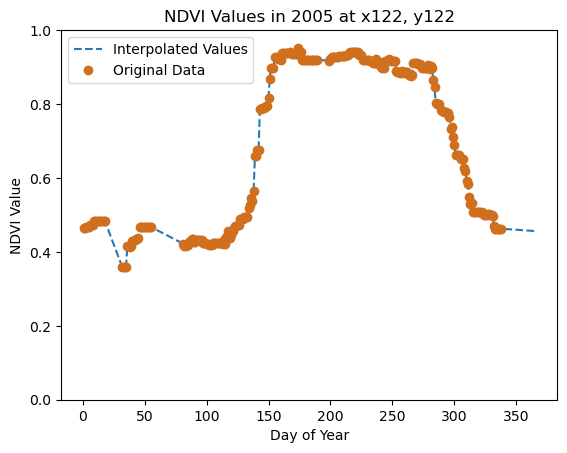

In [60]:
start, end = 186, 365 # Start and end indexes
pixel = (122, 122) # Pixel we're looking at (x122, y122 is the textbook example of NDVI over the course of the year, other pixels aren't as pretty, but that's what the smoothing is for!)
# Pixel 10, 122; no optimal parameters found

ndvi_rs_int = interpolate_pixel(ndvi_rs, *pixel, display=True) # Interpolate missing ndvi values
autumn_ndvi = np.array((ndvi_rs_int)[start:end]) # Select just the autumn season ndvi values

ndvi_smoothed = smooth_ndvi(ndvi_rs_int) # Smooth the ndvi values using Savisky-Golay filter
autumn_ndvi_smoothed = ndvi_smoothed[start:end] # Select just the fall season smoothed ndvi values

autumn_doy = np.array([i + 1 for i in range(len(ndvi_rs_int))][start:end]) # Create list of doys for the fall season

In [61]:
maxNDVI = max(autumn_ndvi_smoothed)
minNDVI = min(autumn_ndvi_smoothed)
baseNDVI = maxNDVI - minNDVI

print(len(autumn_ndvi_smoothed))

pIn = [baseNDVI, 0.5, baseNDVI, minNDVI] # Initial guess at the parameters to feed into optimize NEED TO REVIEW THIS WITH SPERA... I deviated from Zhang 2011 and Spera 2023 a little bit

179


In [62]:
param, covariance = optimize.curve_fit(f=logistic_fall, xdata=autumn_doy, ydata=autumn_ndvi_smoothed, p0=pIn, sigma=1) # Find the logistic fall equation that fits the NDVI data
print(param) # Parameters of the logistic fall curve from optimize.curve_fit

[-9.69988697  0.08489113  0.46741976  0.45373834]


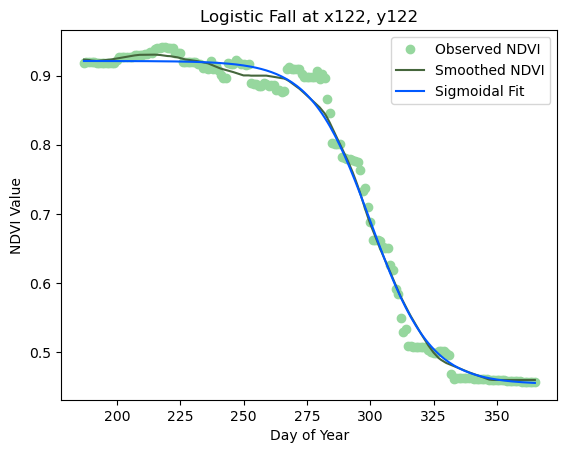

In [ ]:
# Plot the logistic fall curve
plt.plot(autumn_doy, autumn_ndvi, "o", color="#96D79E", label="Observed NDVI")
plt.plot(autumn_doy, autumn_ndvi_smoothed, "-", color="#45663C", label="Smoothed NDVI")
plt.plot(autumn_doy, logistic_fall(autumn_doy, *param), "-", color="#0059FF", label="Sigmoidal Fit")
plt.xlabel("Day of Year")
plt.ylabel("NDVI Value")
plt.title(f"Logistic Fall at x{pixel[0]}, y{pixel[1]}")
plt.legend()
plt.show()

In [64]:
# NBI NEEDS WORK! Something is off about my equation. I was so close too
paramA = param[0]
paramB = param[1]
nbi_autumn = nbi(x=autumn_doy, pA=paramA, pB=paramB) # Calculate NBI using the leaf development parameters from the Logistic Fall Function

print(param)

[-9.69988697  0.08489113  0.46741976  0.45373834]


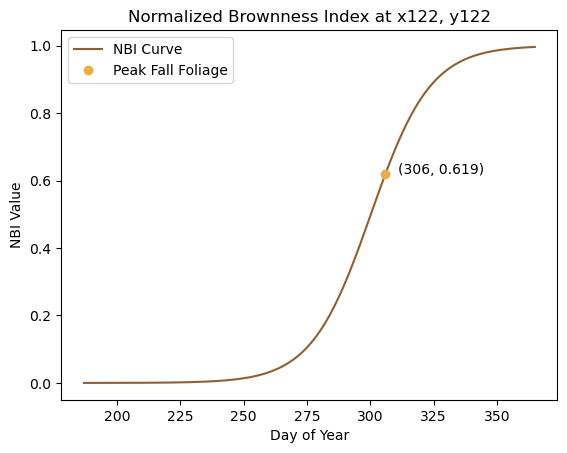

In [65]:
# Plot the NBI curve
plt.plot(autumn_doy, nbi_autumn, "-", color="#915F34", label="NBI Curve")
plt.plot(autumn_doy[np.where(nbi_autumn >= 0.6)[0][0]], nbi_autumn[np.where(nbi_autumn >= 0.6)[0][0]], "o", color="#efab44", label="Peak Fall Foliage")
plt.text(autumn_doy[np.where(nbi_autumn >= 0.6)[0][0]]+5, nbi_autumn[np.where(nbi_autumn >= 0.6)[0][0]], f"({(autumn_doy[np.where(nbi_autumn >= 0.6)[0][0]])}, {nbi_autumn[np.where(nbi_autumn >= 0.6)[0][0]]:.3f})")
plt.xlabel("Day of Year")
plt.ylabel("NBI Value")
plt.title(f"Normalized Brownness Index at x{pixel[0]}, y{pixel[1]}")
plt.legend()
plt.show()

I gained a lot of skills with new python packages (rioxarray, scipy.interpolate, scipy.optimize, scipy.signal) and gained a more in-depth knowledge of other packages like xarray and matplotlib. There was a lot of trial and error involved, so I really got to work on my perseverance. I did learn however, that I need to have a balance between perseverance and knowing when to ask for help, so thank you to Dr. Spera for helping me with the data issues and helping maintain some sense of sanity.

The current limitations of my final project is the size of the data. I would have liked to run the interpolation on all the data I have, however since I have so much data, it isn't feasible. I also needed a little bit more time to figure out the NBI function (however I know that I'm super close). Both of those together explain why I wasn't able to show much in my results section of the project.

Overall I'm impressed with how far I was able to get with this! I will continue to work on this project since it is research I'm doing with Dr. Spera. So in the future, I will get the NBI function all squared away and then actually run the whole interpolation on a dedicated machine. Then, I will create timeseries of how fall foliage has changed over the past 25 years for the whole park, as well as each pixel.